In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

: 

In [282]:
data = pd.read_csv("avocado.csv")
data.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [283]:
data.drop(data.columns[data.columns.str.contains("unnamed", case=False)], axis = 1, inplace = True)
data['Date'] = pd.to_datetime(data['Date'])
data.sort_values(['region', 'Date']).reset_index(drop=True, inplace=True)

le_type = LabelEncoder() # converte para a numeros com o one hot encoding
le_region = LabelEncoder()
data['type'] = le_type.fit_transform(data['type'])
data['region'] = le_region.fit_transform(data['region'])

data.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,0,2015,0
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,0,2015,0
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,0,2015,0
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,0,2015,0
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,0,2015,0


In [284]:
features = ['Total Volume', '4046', '4225', '4770', 'year', 'type', 'region']
target = "AveragePrice"

X = data[features].to_numpy()
Y = data[target].to_numpy()
X

array([[6.4236620e+04, 1.0367400e+03, 5.4454850e+04, ..., 2.0150000e+03,
        0.0000000e+00, 0.0000000e+00],
       [5.4876980e+04, 6.7428000e+02, 4.4638810e+04, ..., 2.0150000e+03,
        0.0000000e+00, 0.0000000e+00],
       [1.1822022e+05, 7.9470000e+02, 1.0914967e+05, ..., 2.0150000e+03,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [1.3766760e+04, 1.1919200e+03, 2.4527900e+03, ..., 2.0180000e+03,
        1.0000000e+00, 5.3000000e+01],
       [1.6205220e+04, 1.5276300e+03, 2.9810400e+03, ..., 2.0180000e+03,
        1.0000000e+00, 5.3000000e+01],
       [1.7489580e+04, 2.8947700e+03, 2.3561300e+03, ..., 2.0180000e+03,
        1.0000000e+00, 5.3000000e+01]], shape=(18249, 7))

In [285]:
sc_X = MinMaxScaler(feature_range=(0,1))
X_scaled = sc_X.fit_transform(X)
sc_Y = MinMaxScaler(feature_range=(0,1))
Y_scaled = sc_Y.fit_transform(Y.reshape(-1, 1))
X_scaled

array([[1.02634162e-03, 4.55837802e-05, 2.66015275e-03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [8.76600710e-04, 2.96470005e-05, 2.18063319e-03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.89000237e-03, 3.49416730e-05, 5.33202818e-03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [2.18895720e-04, 5.24067937e-05, 1.19820293e-04, ...,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [2.57907608e-04, 6.71674191e-05, 1.45625628e-04, ...,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [2.78455540e-04, 1.27278353e-04, 1.15098392e-04, ...,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00]], shape=(18249, 7))

In [286]:
def create_sequences(X, Y, time_steps=10):
    Xs, Ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i+time_steps)])
        Ys.append(Y[i + time_steps])
    return np.array(Xs), np.array(Ys)

time_steps = 10
X_seq, Y_seq = create_sequences(X_scaled, Y_scaled, time_steps)
print(X_seq.shape, Y_seq.shape)


(18239, 10, 7) (18239, 1)


In [287]:
train_size = int(len(X_seq) * 0.75)
X_train, X_test = X_seq[:train_size], X_seq[train_size:]
Y_train, Y_test = Y_seq[:train_size], Y_seq[train_size:]

In [288]:
model = Sequential([
    GRU(units=50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    GRU(units=50, activation='relu'),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()


c:\Users\guilh\Documents\College_Stuff\Inteligencia artificial\Atividades\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_50 (GRU)                    │ (None, 10, 50)         │         8,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_51 (GRU)                    │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,201 (94.54 KB)

 Trainable params: 24,201 (94.54 KB)

 Non-trainable params: 0 (0.00 B)

In [289]:
history = model.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0102 - val_loss: 0.0188
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0080 - val_loss: 0.0193
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0077 - val_loss: 0.0202
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0076 - val_loss: 0.0188
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0075 - val_loss: 0.0209
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0073 - val_loss: 0.0186
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0074 - val_loss: 0.0204
Epoch 8/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0073 - val_loss: 0.0183
Epoch 9/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0072 - val_loss: 0.0191
Epoch 10/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0072 - val_loss: 0.0180
Epoch 11/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0071 - val_loss: 0.0195
Epoch 12/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

In [290]:
from sklearn.metrics import mean_squared_error, r2_score

Y_pred_scaled = model.predict(X_test)
Y_pred = sc_Y.inverse_transform(Y_pred_scaled)
Y_true = sc_Y.inverse_transform(Y_test)

mse = mean_squared_error(Y_true, Y_pred)
r2 = r2_score(Y_true, Y_pred)

print(f"\nErro Quadrático Médio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinação (R2): {r2:.4f}")


143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Erro Quadrático Médio (MSE): 0.20
Coeficiente de Determinação (R2): -0.2101


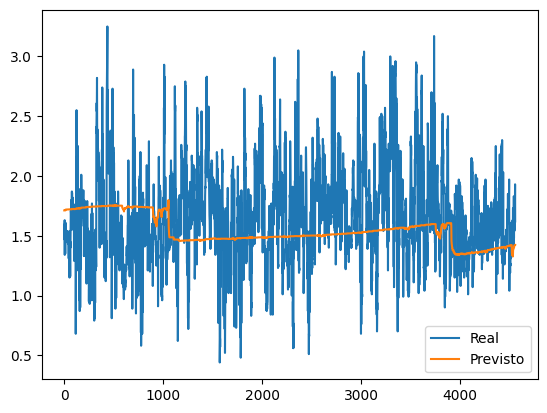

In [291]:
import matplotlib.pyplot as plt
plt.plot(Y_true, label="Real")
plt.plot(Y_pred, label="Previsto")
plt.legend()
plt.show()

Date - The date of the observation  
AveragePrice - the average price of a single avocado  
type - conventional or organic  
year - the year  
Region - the city or region of the observation  
Total Volume - Total number of avocados sold  
4046 - Total number of avocados with PLU 4046 sold  
4225 - Total number of avocados with PLU 4225 sold  
4770 - Total number of avocados with PLU 4770 sold  